# DQN Stable-Baselines3 sur highway-v0

In [1]:
import os, json, datetime
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import highway_env
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG

## 01. Configuration

In [2]:
SEEDS = [0, 1, 2]
TOTAL_TIMESTEPS = 75000
EVAL_EPISODES = 50
N_ENVS = 8  # nombre d'environnements parallèles

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
SAVE_DIR = os.path.join("checkpoints_sb", f"run_{RUN_ID}")
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Envs parallèles: {N_ENVS}")
print(f"Save dir: {SAVE_DIR}")

Device: cuda
Envs parallèles: 8
Save dir: checkpoints_sb\run_20260403-105821


## 02. Environnement

In [3]:
def make_env(seed=0):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode="rgb_array")
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset(seed=seed)
    return env


def make_vec_env(n_envs, seed=0):
    """Crée n_envs environnements via DummyVecEnv."""
    def _make(rank):
        def _init():
            env = gym.make(SHARED_CORE_ENV_ID, render_mode="rgb_array")
            env.unwrapped.configure(SHARED_CORE_CONFIG)
            env.reset(seed=seed + rank)
            return env
        return _init
    return DummyVecEnv([_make(i) for i in range(n_envs)])

## 03. Entraînement multi-seed
Callback simple pour logger les rewards par épisode.

In [4]:
class _RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._ep_rewards = None

    def _on_training_start(self):
        self._ep_rewards = np.zeros(self.training_env.num_envs)

    def _on_step(self):
        self._ep_rewards += self.locals["rewards"]
        for i, done in enumerate(self.locals["dones"]):
            if done:
                self.episode_rewards.append(self._ep_rewards[i])
                self._ep_rewards[i] = 0.0
        return True


trained_models = {}
training_rewards = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"  Seed {seed}")
    print(f"{'='*50}")

    env = make_vec_env(N_ENVS, seed=seed)

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=5e-4,
        buffer_size=15_000,
        learning_starts=200,
        batch_size=256,
        gamma=0.99,
        target_update_interval=50,
        train_freq=(4, "step"),
        gradient_steps=8,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        exploration_fraction=0.5,
        policy_kwargs=dict(net_arch=[256, 256]),
        device=DEVICE,
        seed=seed,
        verbose=0,
    )

    logger = _RewardLogger()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logger, progress_bar=True)

    model.save(os.path.join(SAVE_DIR, f"dqn_seed{seed}"))
    trained_models[seed] = model
    training_rewards[seed] = logger.episode_rewards
    env.close()

    print(f"  {len(logger.episode_rewards)} episodes")


  Seed 0


Output()

  5640 episodes

  Seed 1


Output()

Output()

  3767 episodes

  Seed 2


  3304 episodes


## 04. Courbes d'entraînement

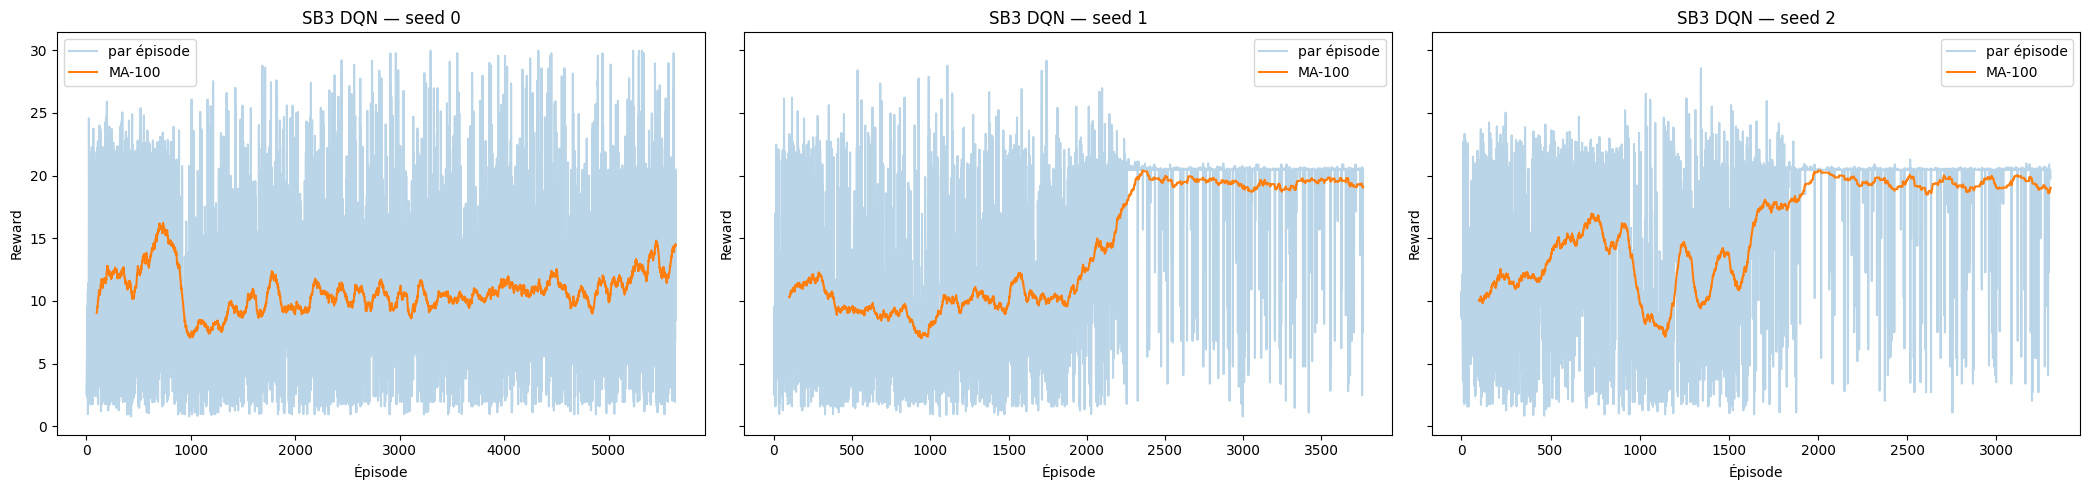

In [5]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(7 * len(SEEDS), 5), sharey=True)
if len(SEEDS) == 1:
    axes = [axes]

window = 100
for ax, seed in zip(axes, SEEDS):
    r = np.array(training_rewards[seed])
    ax.plot(r, alpha=0.3, label="par épisode")
    if len(r) >= window:
        smooth = np.convolve(r, np.ones(window)/window, mode="valid")
        ax.plot(np.arange(window-1, len(r)), smooth, label=f"MA-{window}")
    ax.set_title(f"SB3 DQN \u2014 seed {seed}")
    ax.set_xlabel("Épisode")
    ax.set_ylabel("Reward")
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "sb3_training_curves.png"), dpi=150)
plt.show()

## 05. Évaluation (50 épisodes par seed)

In [6]:
def evaluate_sb3(model, n_episodes=50, seed_offset=1000):
    env = make_env(seed=seed_offset)
    rewards, lengths, crashes = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + ep)
        done, total_r, steps = False, 0.0, 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = env.step(int(action))
            total_r += r
            steps += 1
            done = terminated or truncated
        rewards.append(total_r)
        lengths.append(steps)
        crashes.append(info.get("crashed", False))

    env.close()
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_length": float(np.mean(lengths)),
        "std_length": float(np.std(lengths)),
        "crash_rate": float(np.mean(crashes)),
        "raw_rewards": [float(x) for x in rewards],
    }


eval_results = {}
for seed in SEEDS:
    res = evaluate_sb3(trained_models[seed], n_episodes=EVAL_EPISODES)
    eval_results[seed] = res
    print(f"seed={seed}  reward={res['mean_reward']:.2f} +/- {res['std_reward']:.2f}  "
          f"crash_rate={res['crash_rate']:.0%}  length={res['mean_length']:.1f}")

seed=0  reward=20.10 +/- 2.48  crash_rate=6%  length=29.2
seed=1  reward=19.35 +/- 3.84  crash_rate=8%  length=28.5
seed=2  reward=19.98 +/- 2.42  crash_rate=4%  length=29.3


## 06. Sauvegarde des résultats

In [7]:
summary = {
    "algorithm": "SB3 DQN",
    "total_timesteps": TOTAL_TIMESTEPS,
    "gamma": 0.99,
    "lr": 5e-4,
    "buffer_size": 15000,
    "batch_size": 32,
    "net_arch": [256, 256],
    "seeds": SEEDS,
    "eval_episodes": EVAL_EPISODES,
    "per_seed": {},
}

all_means = []
for seed in SEEDS:
    summary["per_seed"][str(seed)] = eval_results[seed]
    all_means.append(eval_results[seed]["mean_reward"])

summary["cross_seed_mean_reward"] = float(np.mean(all_means))
summary["cross_seed_std_reward"] = float(np.std(all_means))
summary["cross_seed_mean_crash_rate"] = float(np.mean([eval_results[s]["crash_rate"] for s in SEEDS]))

metrics_path = os.path.join(SAVE_DIR, "sb3_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Metrics saved -> {metrics_path}")

print(f"\nCross-seed: reward={summary['cross_seed_mean_reward']:.2f} +/- {summary['cross_seed_std_reward']:.2f}")
print(f"Cross-seed crash rate: {summary['cross_seed_mean_crash_rate']:.0%}")

Metrics saved -> checkpoints_sb\run_20260403-105821\sb3_metrics.json

Cross-seed: reward=19.81 +/- 0.33
Cross-seed crash rate: 6%


## 07. Graphique d'évaluation

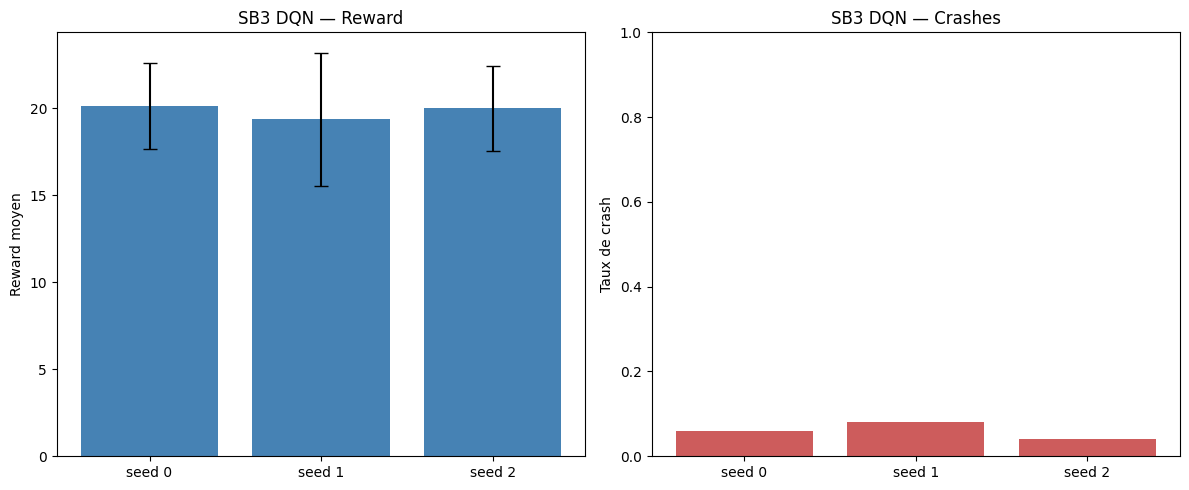

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

means = [eval_results[s]["mean_reward"] for s in SEEDS]
stds = [eval_results[s]["std_reward"] for s in SEEDS]
crash_rates = [eval_results[s]["crash_rate"] for s in SEEDS]

x = np.arange(len(SEEDS))
ax1.bar(x, means, yerr=stds, capsize=5, color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels([f"seed {s}" for s in SEEDS])
ax1.set_ylabel("Reward moyen")
ax1.set_title("SB3 DQN \u2014 Reward")

ax2.bar(x, crash_rates, color="indianred")
ax2.set_xticks(x)
ax2.set_xticklabels([f"seed {s}" for s in SEEDS])
ax2.set_ylabel("Taux de crash")
ax2.set_ylim(0, 1)
ax2.set_title("SB3 DQN \u2014 Crashes")

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "sb3_eval_results.png"), dpi=150)
plt.show()

## 08. Vidéo du meilleur seed

In [9]:
best_seed = SEEDS[int(np.argmax(means))]
best_model = trained_models[best_seed]

video_dir = os.path.join(SAVE_DIR, f"rollout_seed{best_seed}")
os.makedirs(video_dir, exist_ok=True)

env = gym.make(SHARED_CORE_ENV_ID, render_mode="rgb_array")
env.unwrapped.configure(SHARED_CORE_CONFIG)
env = gym.wrappers.RecordVideo(env, video_dir, episode_trigger=lambda e: e < 3)

for ep in range(3):
    obs, _ = env.reset(seed=best_seed + ep)
    done = False
    total_r = 0.0
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(int(action))
        total_r += r
        done = terminated or truncated
    print(f"Episode {ep}: reward={total_r:.3f}")

env.close()
print(f"Videos saved -> {video_dir}")

c:\Users\JB\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\JB\Desktop\RL-project\checkpoints_sb\run_20260403-105821\rollout_seed0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 0: reward=20.455
Episode 1: reward=20.455
Episode 2: reward=20.455
Videos saved -> checkpoints_sb\run_20260403-105821\rollout_seed0
